In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time 
import os
import logging
from torch.utils.data import DataLoader
from torchvision import models

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [3]:
data_path = './data1'
batch_size = 128
learning_rate = 0.001
num_epochs = 3
num_classes = 10
image_size = 128

logging.info(f"Размер данных: {batch_size}")
logging.info(f"Скорость обучения: {learning_rate}")
logging.info(f"Количество эпох: {num_epochs}")

print(f"Размер батча: {batch_size}")
print(f"Скорость обучения: {learning_rate}")
print(f"Количество эпох: {num_epochs}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Размер батча: 128
Скорость обучения: 0.001
Количество эпох: 3
Используется: cuda
GPU: Tesla T4


In [ ]:
logging.info("Начинаем загрузку и подготовку данных CIFAR-10")
print("Начинаем загрузку и подготовку данных CIFAR-10")
transform_train = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation (degrees = 15),
    transforms.ColorJitter( brightness= 0.2, contrast= 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

print("Загружаем CIFAR-10")

train_dataset = torchvision.datasets.CIFAR10(
    root = data_path,
    train = True,
    download = True,
    transform = transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root = data_path,
    train = False, 
    download = True,
    transform = transform_test
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = batch_size, 
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

print(f"Данные загружены")
print(f"Обучающих: {len(train_dataset)}")
print(f"Тестовых: {len(test_dataset)}")
print(f"Размер батча: {batch_size}")


Начинаем загрузку и подготовку данных CIFAR-10
Загружаем CIFAR-10


100%|██████████| 170M/170M [00:03<00:00, 44.1MB/s] 


Данные загружены
Обучающих: 50000
Тестовых: 10000
Размер батча: 128


In [5]:
def create_models (model_name = 'resnet50', num_classes = 10, freeze_backbone = True, pretrained = True):

    if model_name == 'resnet50':
        model = models.resnet50(pretrained = pretrained)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)

    elif model_name == 'vgg16':
        model = models.vgg16(pretrained = pretrained)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        num_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_features, num_classes)

    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2 (pretrained = pretrained)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, num_classes) 

    elif model_name == 'densenet121':
        model = models.densenet121 (pretrained = pretrained)

        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, num_classes)

    else:
        raise ValueError(f"Модель '{model_name}' не поддерживается"
                         f"Доступные: resnet50, vgg16, mobilenet_v2, densenet121")
    model = model.to(device)
    return model

In [6]:
def model_info(model, model_name, expetiment_type = ""):
    if expetiment_type:
        title = f"Модель: {model_name} - {expetiment_type}"
    else:
        title = f"Модель: {model_name}"
    print(title)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() 
                          if p.requires_grad)

    print(f"Всего параметров: {total_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,}")
    print(f"Замороженных параметров: {total_params - trainable_params:,}")
    
    if total_params > 0:
        percentage = 100 * trainable_params / total_params
        print(f"Процент обучаемых: {percentage:.2f}%")
    else:
        print("Модель не имеет параметров")

    print(f"Обучаемые параметры")
    has_trainable = False
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            has_trainable = True
            param_str = f"{name:50} {tuple(param.shape)}"
            print(f"{param_str}")
    
    if not has_trainable:
        print("Внимание! Нет обучаемых параметров (вся модель заморожена)")

    print("Основные слои архитектуры:")
    if model_name == 'resnet50':
        layers = list(model.children())[:3] + list(model.children())[-2:]
        for i, layer in enumerate(layers):
            if i < 3:
                print(f"  Слой {i+1} (предобученный): {layer.__class__.__name__}")
            else:
                print(f"  Слой {i+1} (модифицированный): {layer.__class__.__name__}")
    

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return running_loss / len(train_loader), 100. * correct / total

def test_model(model, test_loader, criterion):
    model.eval()  
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    test_loss = test_loss / len(test_loader)
    test_acc = 100. * correct / total
    
    return test_loss, test_acc

def train_and_evaluate(model, model_name, experiment_type, train_loader, test_loader, num_epochs=num_epochs, lr=learning_rate):
    model_info(model, model_name, experiment_type)
    criterion = nn.CrossEntropyLoss()
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(trainable_params, lr=lr)
    print(f"Параметры обучения:")
    print(f"Алгоритм оптимизации: Adam")
    print(f"Learning rate: {lr}")
    print(f"Batch size: {batch_size}")
    print(f"Количество эпох: {num_epochs}")
    print(f"Функция потерь: CrossEntropyLoss")
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    best_acc = 0.0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"Эпоха [{epoch+1}/{num_epochs}]")
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, epoch)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_loss, test_acc = test_model(model, test_loader, criterion)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        if test_acc > best_acc:
            best_acc = test_acc
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.2f}%")
        print(f"Best Test Acc: {best_acc:.2f}%")
    
    total_time = time.time() - start_time
    print(f"Эксперимент завершён: {model_name} - {experiment_type}")
    print(f"Общее время: {total_time/60:.2f} минут")
    print(f"Лучшая точность: {best_acc:.2f}%")
    print(f"Финальная точность: {test_accs[-1]:.2f}%")
    
    return {
        'model_name': model_name,
        'experiment_type': experiment_type,
        'best_test_acc': best_acc,
        'final_test_acc': test_accs[-1],
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'total_time': total_time
    }

In [8]:
import warnings
warnings.filterwarnings('ignore')

print("Начало выполнения эспериментов")
all_results = []
models_to_test = ['resnet50','densenet121', 'mobilenet_v2']
#models_to_test = ['resnet50', 'vgg16', 'mobilenet_v2', 'densenet121']

for model_name in models_to_test:
    print (f"Тестируем модель: {model_name}")
    
    print(f"Эксперимент 1: Частичное обучение")
    model = create_models(
        model_name=model_name,
        num_classes=num_classes,
        freeze_backbone=True,     
        pretrained=True           
    )
    
    result1 = train_and_evaluate(
        model=model,
        model_name=model_name,
        experiment_type="Частичное обучение",
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        lr=learning_rate
    )
    all_results.append(result1)
    
    print(f"Эксперимент 2: Полное обучение")
    model = create_models(
        model_name=model_name,
        num_classes=num_classes,
        freeze_backbone=False,    
        pretrained=True          
    )
    
    result2 = train_and_evaluate(
        model=model,
        model_name=model_name,
        experiment_type="Полное обучение",
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        lr=learning_rate * 0.5
    )
    all_results.append(result2)
    

print(f"Все эксперименты завершены")
print(f"Всего проведено: {len(all_results)} экспериментов")

Начало выполнения эспериментов
Тестируем модель: resnet50
Эксперимент 1: Частичное обучение
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


Модель: resnet50 - Частичное обучение
Всего параметров: 23,528,522
Обучаемых параметров: 20,490
Замороженных параметров: 23,508,032
Процент обучаемых: 0.09%
Обучаемые параметры
fc.weight                                          (10, 2048)
fc.bias                                            (10,)
Основные слои архитектуры:
  Слой 1 (предобученный): Conv2d
  Слой 2 (предобученный): BatchNorm2d
  Слой 3 (предобученный): ReLU
  Слой 4 (модифицированный): AdaptiveAvgPool2d
  Слой 5 (модифицированный): Linear
Параметры обучения:
Алгоритм оптимизации: Adam
Learning rate: 0.001
Batch size: 128
Количество эпох: 3
Функция потерь: CrossEntropyLoss
Эпоха [1/3]
Train Loss: 0.9562, Train Acc: 68.05%
Test Loss:  0.6574, Test Acc:  77.78%
Best Test Acc: 77.78%
Эпоха [2/3]
Train Loss: 0.7903, Train Acc: 72.95%
Test Loss:  0.6185, Test Acc:  78.81%
Best Test Acc: 78.81%
Эпоха [3/3]
Train Loss: 0.7572, Train Acc: 73.74%
Test Loss:  0.6013, Test Acc:  79.51%
Best Test Acc: 79.51%
Эксперимент завершён: resn

100%|██████████| 30.8M/30.8M [00:00<00:00, 115MB/s] 


Модель: densenet121 - Частичное обучение
Всего параметров: 6,964,106
Обучаемых параметров: 10,250
Замороженных параметров: 6,953,856
Процент обучаемых: 0.15%
Обучаемые параметры
classifier.weight                                  (10, 1024)
classifier.bias                                    (10,)
Основные слои архитектуры:
Параметры обучения:
Алгоритм оптимизации: Adam
Learning rate: 0.001
Batch size: 128
Количество эпох: 3
Функция потерь: CrossEntropyLoss
Эпоха [1/3]
Train Loss: 1.0497, Train Acc: 65.42%
Test Loss:  0.7501, Test Acc:  75.67%
Best Test Acc: 75.67%
Эпоха [2/3]
Train Loss: 0.7986, Train Acc: 72.47%
Test Loss:  0.7084, Test Acc:  76.16%
Best Test Acc: 76.16%
Эпоха [3/3]
Train Loss: 0.7613, Train Acc: 73.62%
Test Loss:  0.6861, Test Acc:  76.94%
Best Test Acc: 76.94%
Эксперимент завершён: densenet121 - Частичное обучение
Общее время: 6.91 минут
Лучшая точность: 76.94%
Финальная точность: 76.94%
Эксперимент 2: Полное обучение
Модель: densenet121 - Полное обучение
Всего парам

100%|██████████| 13.6M/13.6M [00:00<00:00, 148MB/s]


Модель: mobilenet_v2 - Частичное обучение
Всего параметров: 2,236,682
Обучаемых параметров: 12,810
Замороженных параметров: 2,223,872
Процент обучаемых: 0.57%
Обучаемые параметры
classifier.1.weight                                (10, 1280)
classifier.1.bias                                  (10,)
Основные слои архитектуры:
Параметры обучения:
Алгоритм оптимизации: Adam
Learning rate: 0.001
Batch size: 128
Количество эпох: 3
Функция потерь: CrossEntropyLoss
Эпоха [1/3]
Train Loss: 1.0509, Train Acc: 64.05%
Test Loss:  0.8889, Test Acc:  70.29%
Best Test Acc: 70.29%
Эпоха [2/3]
Train Loss: 0.8941, Train Acc: 69.03%
Test Loss:  0.8832, Test Acc:  70.18%
Best Test Acc: 70.29%
Эпоха [3/3]
Train Loss: 0.8845, Train Acc: 69.10%
Test Loss:  0.8242, Test Acc:  71.55%
Best Test Acc: 71.55%
Эксперимент завершён: mobilenet_v2 - Частичное обучение
Общее время: 5.08 минут
Лучшая точность: 71.55%
Финальная точность: 71.55%
Эксперимент 2: Полное обучение
Модель: mobilenet_v2 - Полное обучение
Всего па

Анализ результатов
 1. densenet121  [ПОЛН] - 93.43% (12.4 мин)
 2. mobilenet_v2 [ПОЛН] - 92.52% ( 6.9 мин)
 3. resnet50     [ПОЛН] - 91.16% (12.5 мин)
 4. resnet50     [ЧАСТ] - 79.51% ( 6.7 мин)
 5. densenet121  [ЧАСТ] - 76.94% ( 6.9 мин)
 6. mobilenet_v2 [ЧАСТ] - 71.55% ( 5.1 мин)
Лучшая модель: resnet50 - 79.51%


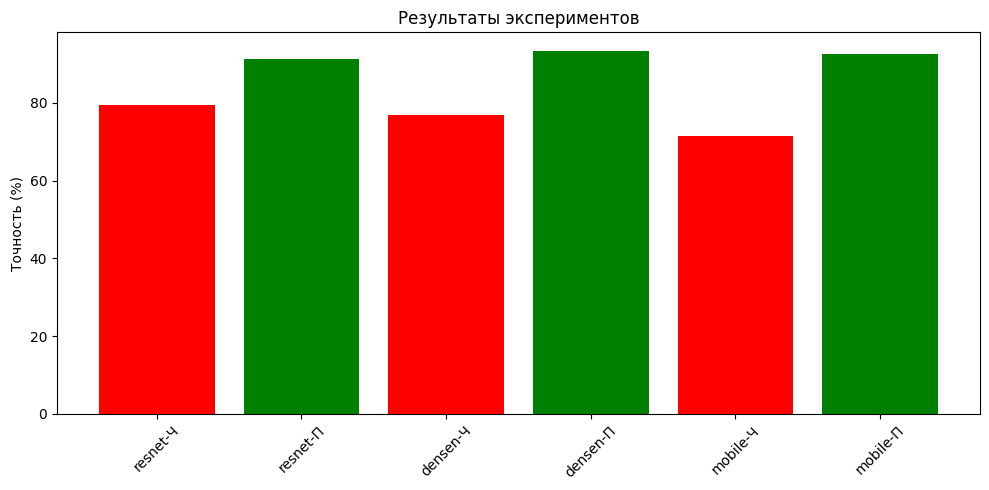

In [9]:
print("Анализ результатов")

for i, res in enumerate(sorted(all_results, key=lambda x: x['best_test_acc'], reverse=True), 1):
    exp = "ЧАСТ" if "Частичное" in res['experiment_type'] else "ПОЛН"
    print(f"{i:2}. {res['model_name']:12} [{exp}] - {res['best_test_acc']:5.2f}% "
          f"({res['total_time']/60:4.1f} мин)")

best = all_results[0]
print(f"Лучшая модель: {best['model_name']} - {best['best_test_acc']:.2f}%")
plt.figure(figsize=(10, 5))
models = [r['model_name'][:6] + ("-Ч" if "Частичное" in r['experiment_type'] else "-П") for r in all_results]
scores = [r['best_test_acc'] for r in all_results]
colors = ['red' if "Частичное" in r['experiment_type'] else 'green' for r in all_results]

plt.bar(models, scores, color=colors)
plt.ylabel('Точность (%)')
plt.title('Результаты экспериментов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()